# Financial Market Analysis in Python

This project compares several financial assets using Python.  
The goal is to analyse return, risk, volatility, drawdown, and risk-adjusted performance.

Assets analysed:

- Apple
- Nvidia
- Tesla
- Bitcoin
- S&P 500
- Gold

In [1]:
# 1. Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.data_loader import download_prices
from src.metrics import calculate_drawdown, calculate_metrics
from src.visualizations import (
    plot_correlation_matrix,
    plot_drawdowns,
    plot_normalized_performance,
    plot_portfolio_comparison,
    plot_portfolio_performance,
    plot_total_returns,
)

In [2]:
tickers = [
    "AAPL",
    "NVDA",
    "TSLA",
    "BTC-USD",
    "^GSPC",
    "GC=F",
]

start_date = "2020-01-01"
end_date = "2026-01-01"

In [3]:
data = download_prices(
    tickers,
    start_date=start_date,
    end_date=end_date,
)

data.head()

Ticker,AAPL,BTC-USD,GC=F,NVDA,TSLA,^GSPC
Date,,,,,,
2020-01-01,NaN,7200.174316,NaN,NaN,NaN,NaN
2020-01-02,72.333870,6985.470215,1524.500000,5.963803,28.684,3257.850098
2020-01-03,71.630646,7344.884277,1549.199951,5.868346,29.534,3234.850098
2020-01-04,NaN,7410.656738,NaN,NaN,NaN,NaN
2020-01-05,NaN,7411.317383,NaN,NaN,NaN,NaN


In [4]:
# 4. Create normalized data
common_prices = data.dropna()

normalized_data = (
    common_prices / common_prices.iloc[0] * 100
)

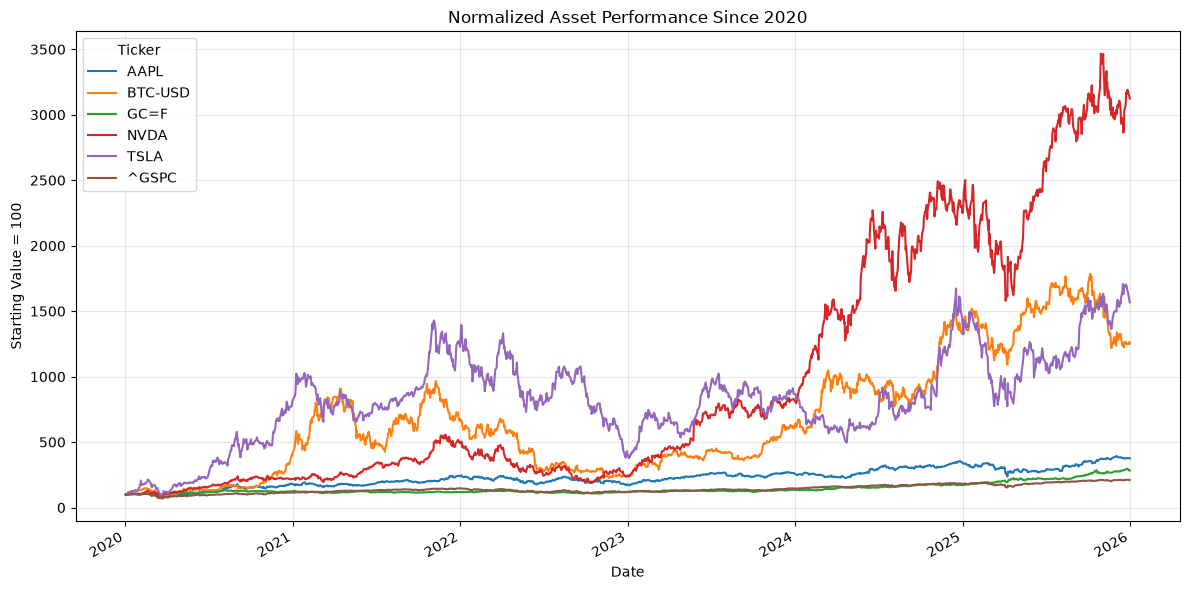

In [5]:
normalized_figure = plot_normalized_performance(
    normalized_data,
    title="Normalized Asset Performance Since 2020",
)

plt.show()

In [6]:
daily_returns = data.pct_change().dropna()

daily_returns.head()

Ticker,AAPL,BTC-USD,GC=F,NVDA,TSLA,^GSPC
Date,,,,,,
2020-01-03,-0.009722,0.051452,0.016202,-0.016006,0.029633,-0.007060
2020-01-07,-0.004703,0.050774,0.003576,0.012107,0.038801,-0.002803
2020-01-08,0.016086,-0.010269,-0.009161,0.001876,0.049205,0.004902
2020-01-09,0.021241,-0.024851,-0.003660,0.010982,-0.021945,0.006655
2020-01-10,0.002260,0.036487,0.003738,0.005349,-0.006627,-0.002855


In [7]:
asset_metrics = pd.DataFrame(
    {
        ticker: calculate_metrics(daily_returns[ticker])
        for ticker in daily_returns.columns
    }
).T

asset_metrics.round(2)

,Total Return (%),Annual Return (%),Annual Volatility (%),Sharpe Ratio,Maximum Drawdown (%)
AAPL,174.56,26.39,31.14,0.85,-28.83
BTC-USD,361.03,48.22,54.98,0.88,-72.68
GC=F,123.41,18.55,16.62,1.12,-18.80
NVDA,1249.43,69.39,52.91,1.31,-55.48
TSLA,62.33,29.58,62.23,0.48,-67.52
^GSPC,82.93,15.03,20.68,0.73,-21.58


In [8]:
drawdowns = pd.DataFrame(
    {
        ticker: calculate_drawdown(daily_returns[ticker]) * 100
        for ticker in daily_returns.columns
    }
)

drawdowns.head()

,AAPL,BTC-USD,GC=F,NVDA,TSLA,^GSPC
Date,,,,,,
2020-01-03,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
2020-01-07,-0.470308,0.000000,0.000000,0.0,0.000000,-0.280324
2020-01-08,0.000000,-1.026859,-0.916149,0.0,0.000000,0.000000
2020-01-09,0.000000,-3.486426,-1.278795,0.0,-2.194501,0.000000
2020-01-10,0.000000,0.000000,-0.909788,0.0,-2.842687,-0.285518


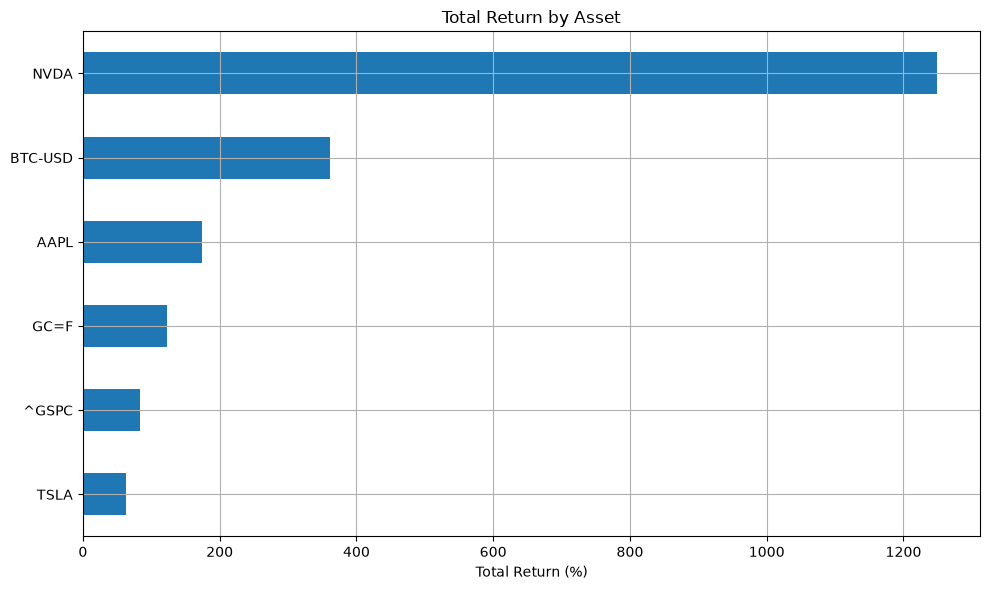

In [9]:
total_returns_figure = plot_total_returns(
    asset_metrics["Total Return (%)"]
)

plt.show()

In [10]:
drawdowns = pd.DataFrame(
    {
        ticker: calculate_drawdown(daily_returns[ticker]) * 100
        for ticker in daily_returns.columns
    }
)

asset_metrics["Maximum Drawdown (%)"].sort_values()

BTC-USD   -72.679306
TSLA      -67.521107
NVDA      -55.482955
AAPL      -28.832442
^GSPC     -21.579858
GC=F      -18.797510
Name: Maximum Drawdown (%), dtype: float64

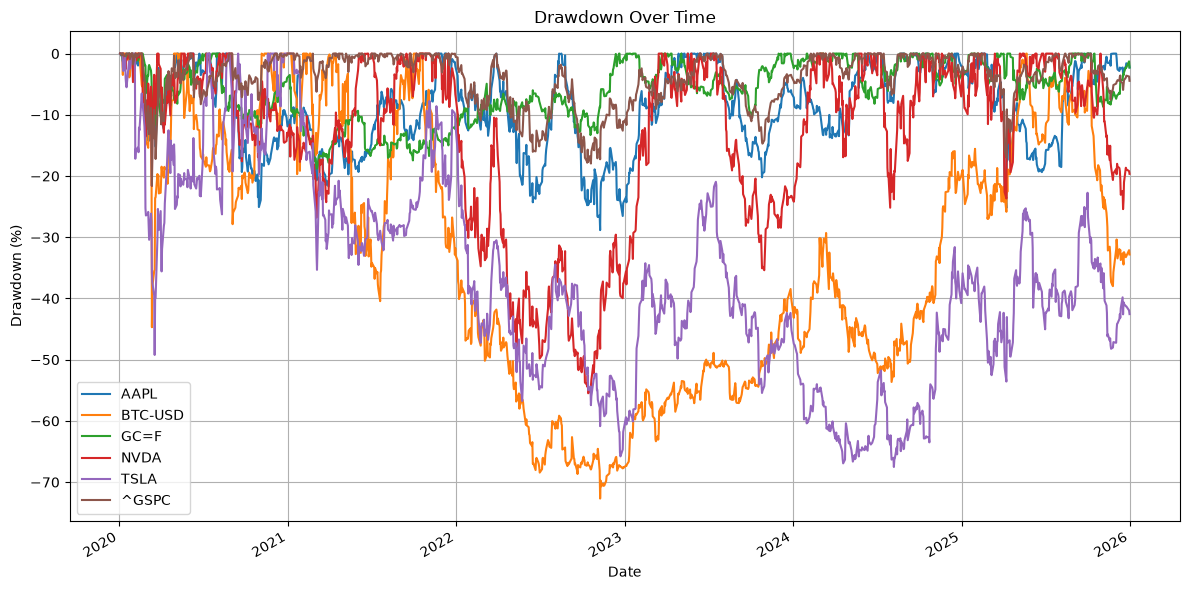

In [11]:
drawdown_figure = plot_drawdowns(drawdowns)

plt.show()

## Conclusion

This project compared Apple, Nvidia, Tesla, Bitcoin, the S&P 500, and gold using historical price data.

The analysis focused on:

- Total return
- Annual return
- Annual volatility
- Sharpe ratio
- Maximum drawdown

The asset with the highest total return was: Nvidia (NVDA), with a total return of about 3023%.

The asset with the highest volatility was: Tesla (TSLA), with annual volatility of about 66.6%.

The asset with the best Sharpe ratio was: Nvidia (NVDA), with a Sharpe ratio of about 1.35.

The asset with the worst maximum drawdown was: Bitcoin (BTC-USD), with a maximum drawdown of about -76.6%.

Overall, this project helped me practise Python, pandas, NumPy, matplotlib, financial data analysis, and basic risk-return analysis.

## Correlation Matrix

This section analyses how closely the assets move together.  
Correlation helps show whether assets tend to rise and fall at the same time.

A correlation close to 1 means two assets move very similarly.  
A correlation close to 0 means they do not have a strong relationship.  
A negative correlation means they often move in opposite directions.

In [12]:
correlation_matrix = daily_returns.corr()

correlation_matrix

Ticker,AAPL,BTC-USD,GC=F,NVDA,TSLA,^GSPC
Ticker,,,,,,
AAPL,1.000000,0.307644,0.086503,0.593701,0.474286,0.785135
BTC-USD,0.307644,1.000000,0.098769,0.310706,0.316981,0.408478
GC=F,0.086503,0.098769,1.000000,0.068031,0.072720,0.120877
NVDA,0.593701,0.310706,0.068031,1.000000,0.471067,0.714958
TSLA,0.474286,0.316981,0.072720,0.471067,1.000000,0.532675
^GSPC,0.785135,0.408478,0.120877,0.714958,0.532675,1.000000


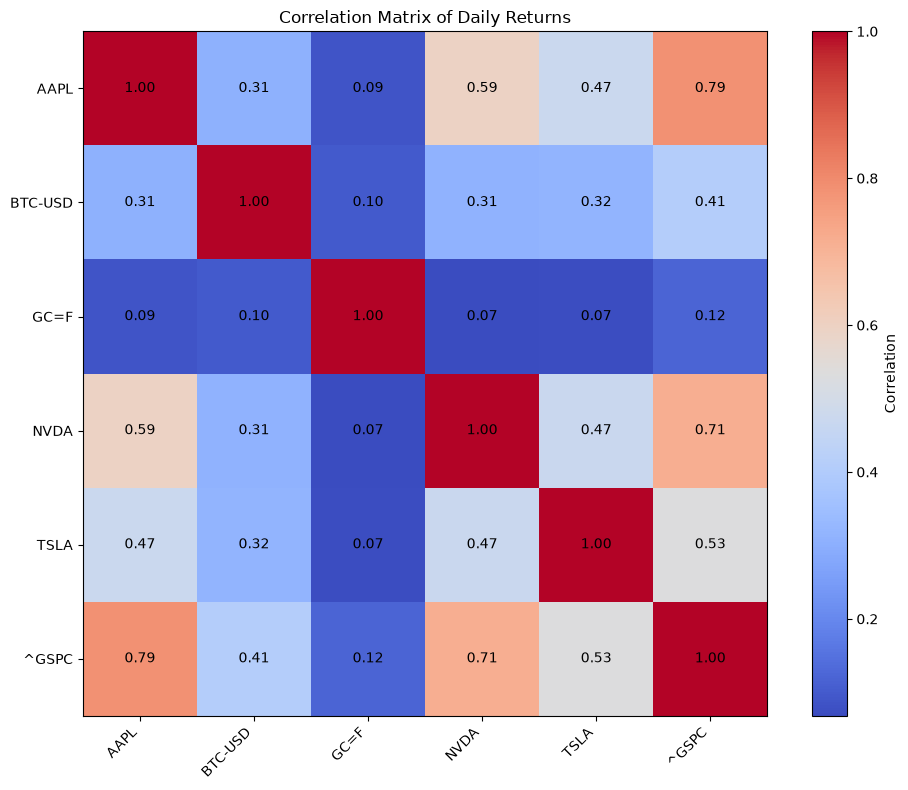

In [13]:
correlation_figure = plot_correlation_matrix(
    correlation_matrix
)

plt.show()

## Equal-Weight Portfolio

This section creates a simple portfolio where each asset has the same weight.

The goal is to compare the performance of a diversified portfolio against individual assets.

This model assumes the portfolio is rebalanced to equal weights each trading day. Transaction costs, taxes, and a non-zero risk-free rate are not included.

In [14]:
portfolio_returns = daily_returns.mean(axis=1)

portfolio_cumulative = (1 + portfolio_returns).cumprod() * 100

portfolio_cumulative.head()

Date
2020-01-03    101.074983
2020-01-07    102.721668
2020-01-08    103.622862
2020-01-09    103.422918
2020-01-10    104.083998
dtype: float64

In [15]:
portfolio_metrics = calculate_metrics(portfolio_returns)
portfolio_metrics

Total Return (%)         317.321262
Annual Return (%)         34.527734
Annual Volatility (%)     28.282742
Sharpe Ratio               1.220806
Maximum Drawdown (%)     -36.163765
dtype: float64

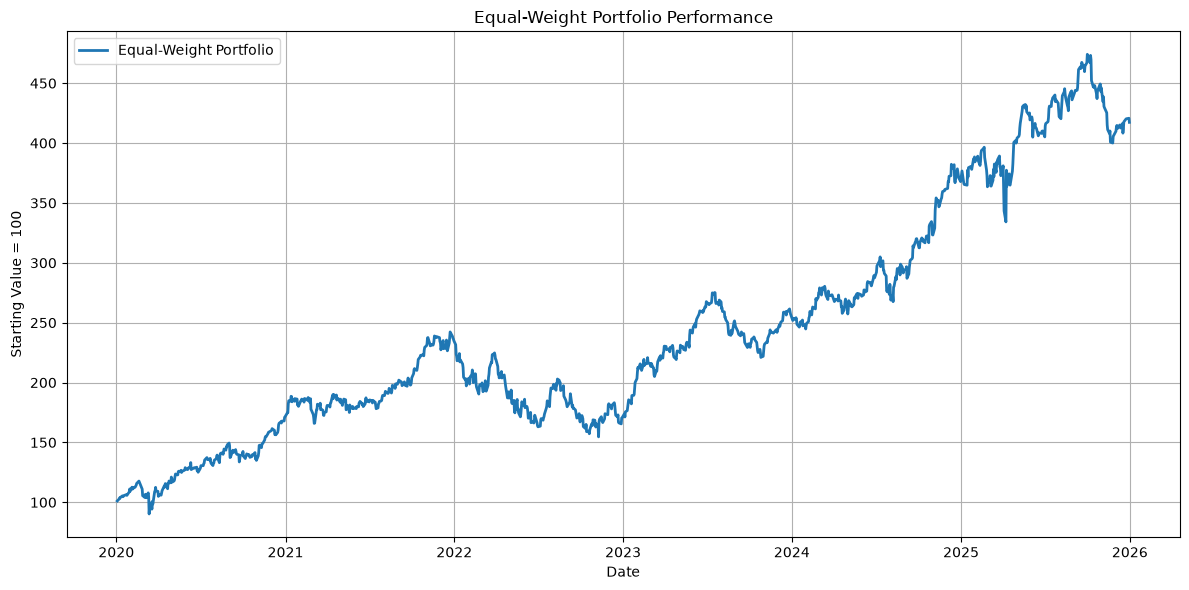

In [16]:
portfolio_figure = plot_portfolio_performance(
    portfolio_cumulative
)

plt.show()

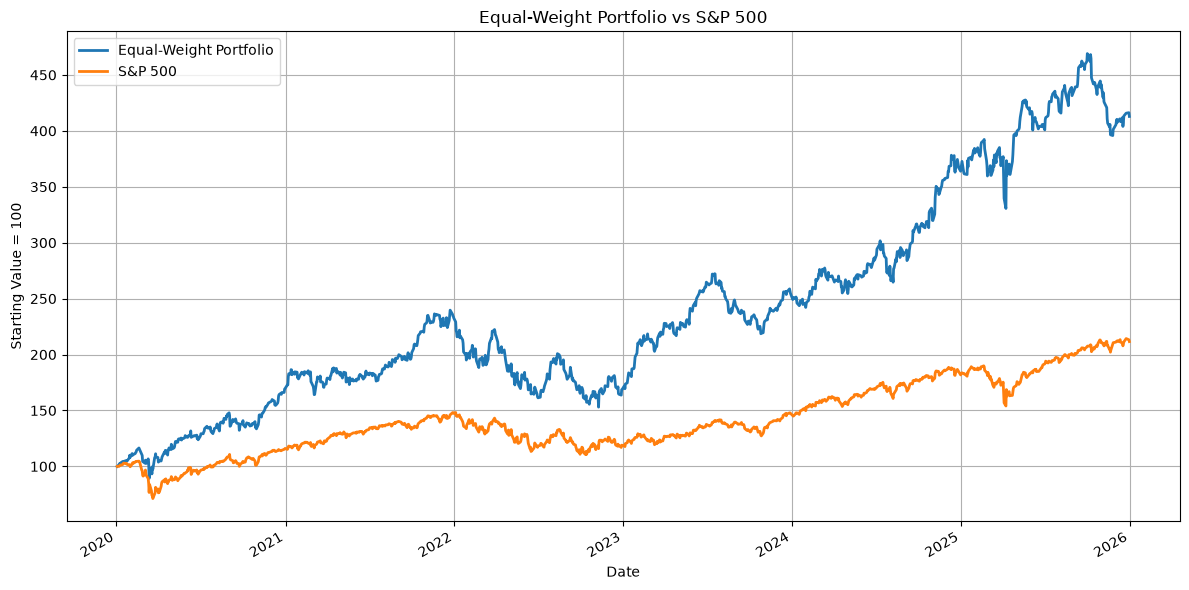

In [19]:
comparison = pd.DataFrame({
    "Equal-Weight Portfolio": portfolio_cumulative,
    "S&P 500": normalized_data["^GSPC"]
}).dropna()

# Make both series start at exactly 100 on the same date
comparison = comparison / comparison.iloc[0] * 100

comparison_figure = plot_portfolio_comparison(
    comparison
)

plt.show()

In [18]:
portfolio_total_return = ((1 + portfolio_returns).prod() - 1) * 100
portfolio_annual_return = portfolio_returns.mean() * 252 * 100
portfolio_annual_volatility = portfolio_returns.std() * np.sqrt(252) * 100
portfolio_sharpe_ratio = portfolio_annual_return / portfolio_annual_volatility

portfolio_cumulative_returns = (1 + portfolio_returns).cumprod()
portfolio_running_max = portfolio_cumulative_returns.cummax()
portfolio_drawdown = (portfolio_cumulative_returns / portfolio_running_max - 1) * 100
portfolio_max_drawdown = portfolio_drawdown.min()

portfolio_summary = pd.DataFrame({
    "Metric": [
        "Total Return (%)",
        "Annual Return (%)",
        "Annual Volatility (%)",
        "Sharpe Ratio",
        "Maximum Drawdown (%)"
    ],
    "Equal-Weight Portfolio": [
        portfolio_total_return,
        portfolio_annual_return,
        portfolio_annual_volatility,
        portfolio_sharpe_ratio,
        portfolio_max_drawdown
    ]
})

portfolio_summary

,Metric,Equal-Weight Portfolio
0,Total Return (%),317.321262
1,Annual Return (%),34.527734
2,Annual Volatility (%),28.282742
3,Sharpe Ratio,1.220806
4,Maximum Drawdown (%),-36.163765


## Version 2 Conclusion

In Version 2, I added a correlation matrix and an equal-weight portfolio.

The correlation matrix helped show how strongly the assets moved together.

The equal-weight portfolio showed how combining different assets can reduce dependence on one single asset and create a more diversified investment profile.

This upgrade helped me practise correlation analysis, portfolio construction, diversification, and financial data visualisation.